In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rxr
import pickle
from astropy.time import Time

### Load ICESat-2 data downloaded in Grand Mesa Demo:

In [2]:
atl06sr_gdf = pickle.load(open('../data/temp/gdf_1m_sierras_concat_sorted.pkl', 'rb'))
atl06sr_gdf

,pflags,h_mean,n_fit_photons,region,w_surface_window_final,dh_fit_dx,cycle,segment_id,h_sigma,rms_misfit,...,geometry,3dep.flags,3dep.file_id,3dep.time,3dep.value,3dep,time_acq,snow_depth,acqdate,is2_1m_dif
time,,,,,,,,,,,,,,,,,,,,,
2021-10-12 07:30:24.762091008,0,457.365481,11,6,5.061572,0.197039,13,787033,0.112457,0.304871,...,POINT (-120.98065 38.72176),NaN,NaN,NaN,NaN,NaN,2021-10-12 07:30:24.762091008,NaN,2021-10-12,NaN
2021-10-12 07:30:24.759267328,0,453.521283,12,6,4.588598,0.178340,13,787032,0.147901,0.509555,...,POINT (-120.98063 38.72194),NaN,NaN,NaN,NaN,NaN,2021-10-12 07:30:24.759267328,NaN,2021-10-12,NaN
2021-10-12 07:30:24.753623040,0,449.772409,17,6,3.000000,0.033152,13,787030,0.050090,0.204083,...,POINT (-120.98058 38.7223),NaN,NaN,NaN,NaN,NaN,2021-10-12 07:30:24.753623040,NaN,2021-10-12,NaN
2021-10-12 07:30:24.750803456,0,449.011704,19,6,3.000000,0.041241,13,787029,0.039575,0.170263,...,POINT (-120.98056 38.72248),NaN,NaN,NaN,NaN,NaN,2021-10-12 07:30:24.750803456,NaN,2021-10-12,NaN
2021-10-12 07:30:24.747986176,0,448.236828,14,6,3.000000,0.034019,13,787028,0.053511,0.199658,...,POINT (-120.98053 38.72266),NaN,NaN,NaN,NaN,NaN,2021-10-12 07:30:24.747986176,NaN,2021-10-12,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-10-19 12:24:27.151114752,0,372.008282,44,2,3.000000,-0.056356,9,218683,0.041532,0.260381,...,POINT (-121.39011 39.41414),NaN,NaN,NaN,NaN,NaN,2020-10-19 12:24:27.151114752,NaN,2020-10-19,NaN
2020-10-19 12:24:27.148294400,0,373.008928,51,2,3.000000,-0.041907,9,218682,0.034748,0.248000,...,POINT (-121.39008 39.41396),NaN,NaN,NaN,NaN,NaN,2020-10-19 12:24:27.148294400,NaN,2020-10-19,NaN
2020-10-19 12:24:27.145472256,0,373.652265,44,2,3.000000,-0.020680,9,218681,0.047132,0.311528,...,POINT (-121.39006 39.41378),NaN,NaN,NaN,NaN,NaN,2020-10-19 12:24:27.145472256,NaN,2020-10-19,NaN


In [52]:
sierras = gpd.read_file('../data/misc/sierras_polygon_gmba.geojson')

### Load reanalysis data for the fsca:

In [3]:
reanalysis_2021 = xr.open_dataset('../data/reanalysis/reanalysis_sierras_processed_2021.nc')

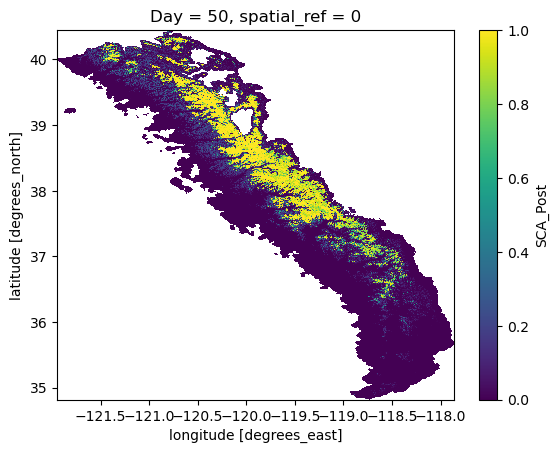

In [68]:
reanalysis_2021.SCA_Post[50].plot()

In [4]:
import datetime

def day_of_year(date):
    # Check if it's a leap year
    leap_year = date.year % 4 == 0 and (date.year % 100 != 0 or date.year % 400 == 0)
    
    # Define days in each month, accounting for leap year
    days_in_month = [31, 29 if leap_year else 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    # Calculate day of the year
    day_count = sum(days_in_month[i] for i in range(date.month - 1)) + date.day
    
    return day_count

# Example usage
date = datetime.date(2024, 5, 9)
print("Day of the year:", day_of_year(date))

Day of the year: 130


In [4]:
#Add DOY and DOWY column
def add_dowy(df, col=None):
    print("Adding Day of Water Year (DOWY)")
    if col is None:
        df['doy'] = df.index.dayofyear
        df['decyear'] = Time(df.index).decimalyear
    else:
        df['doy'] = pd.to_datetime(df[col]).dt.dayofyear
        df['decyear'] = Time(pd.to_datetime(df[col])).decimalyear
    
    #df['dowy'] = (df['doy'].index - pd.DateOffset(months=9)).dayofyear
    # Sept 30 is doy 273
    df['dowy'] = df['doy'] - 273
    df.loc[df['dowy'] <= 0, 'dowy'] += 365

In [5]:
add_dowy(atl06sr_gdf)

Adding Day of Water Year (DOWY)


In [7]:
atl06sr_gdf.columns

Index(['pflags', 'h_mean', 'n_fit_photons', 'region', 'w_surface_window_final',
       'dh_fit_dx', 'cycle', 'segment_id', 'h_sigma', 'rms_misfit', 'spot',
       'y_atc', 'x_atc', 'gt', 'rgt', 'geometry', '3dep.flags', '3dep.file_id',
       '3dep.time', '3dep.value', '3dep', 'time_acq', 'snow_depth', 'acqdate',
       'is2_1m_dif', 'doy', 'decyear', 'dowy'],
      dtype='object')

In [8]:
atl06sr_gdf['acqdate'].unique()

array([datetime.date(2021, 10, 12), datetime.date(2021, 10, 9),
       datetime.date(2021, 10, 8), datetime.date(2021, 10, 5),
       datetime.date(2021, 10, 4), datetime.date(2021, 9, 30),
       datetime.date(2021, 9, 26), datetime.date(2021, 9, 18),
       datetime.date(2021, 9, 14), datetime.date(2021, 9, 13),
       datetime.date(2021, 9, 6), datetime.date(2021, 9, 5),
       datetime.date(2021, 9, 2), datetime.date(2021, 9, 1),
       datetime.date(2021, 8, 28), datetime.date(2021, 8, 15),
       datetime.date(2021, 8, 12), datetime.date(2021, 8, 11),
       datetime.date(2021, 8, 8), datetime.date(2021, 8, 4),
       datetime.date(2021, 8, 3), datetime.date(2021, 7, 14),
       datetime.date(2021, 7, 10), datetime.date(2021, 7, 9),
       datetime.date(2021, 7, 6), datetime.date(2021, 7, 5),
       datetime.date(2021, 7, 2), datetime.date(2021, 6, 27),
       datetime.date(2021, 6, 8), datetime.date(2021, 6, 6),
       datetime.date(2021, 6, 2), datetime.date(2021, 5, 29),
     

In [9]:
len(atl06sr_gdf['acqdate'].unique())

71

In [22]:
atl06sr_gdf['acqdate'].unique()

array([datetime.date(2021, 10, 12), datetime.date(2021, 10, 9),
       datetime.date(2021, 10, 8), datetime.date(2021, 10, 5),
       datetime.date(2021, 10, 4), datetime.date(2021, 9, 30),
       datetime.date(2021, 9, 26), datetime.date(2021, 9, 18),
       datetime.date(2021, 9, 14), datetime.date(2021, 9, 13),
       datetime.date(2021, 9, 6), datetime.date(2021, 9, 5),
       datetime.date(2021, 9, 2), datetime.date(2021, 9, 1),
       datetime.date(2021, 8, 28), datetime.date(2021, 8, 15),
       datetime.date(2021, 8, 12), datetime.date(2021, 8, 11),
       datetime.date(2021, 8, 8), datetime.date(2021, 8, 4),
       datetime.date(2021, 8, 3), datetime.date(2021, 7, 14),
       datetime.date(2021, 7, 10), datetime.date(2021, 7, 9),
       datetime.date(2021, 7, 6), datetime.date(2021, 7, 5),
       datetime.date(2021, 7, 2), datetime.date(2021, 6, 27),
       datetime.date(2021, 6, 8), datetime.date(2021, 6, 6),
       datetime.date(2021, 6, 2), datetime.date(2021, 5, 29),
     

In [7]:
atl06sr_gdf['dowy'].unique()

array([ 12,   9,   8,   5,   4, 365, 361, 353, 349, 348, 341, 340, 337,
       336, 332, 319, 316, 315, 312, 308, 307, 287, 283, 282, 279, 278,
       275, 270, 251, 249, 245, 241, 224, 218, 216, 212, 201, 197, 195,
       193, 189, 183, 179, 168, 164, 162, 160, 158, 156, 143, 139, 127,
       125, 110, 102,  98,  93,  82,  74,  70,  68,  64,  60,  49,  47,
        45,  43,  41,  35,  31,  20], dtype=int32)

In [8]:
reanalysis_2021.SCA_Post

<xarray.DataArray 'SCA_Post' (Day: 365, y: 1267, x: 919)> Size: 2GB
[424996145 values with dtype=float32]
Coordinates:
  * Day          (Day) int64 3kB 0 1 2 3 4 5 6 7 ... 358 359 360 361 362 363 364
  * y            (y) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * x            (x) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
    spatial_ref  int64 8B ...
Attributes:
    Units:    [-]

In [9]:
# 2021:

for date_index in atl06sr_gdf['dowy'].unique():
    reanalysis = reanalysis_2021.SD_Post[date_index-1]
    reanalysis_fsca = reanalysis_2021.SCA_Post[date_index-1]
    x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index)].to_crs('epsg:4326').geometry]
    y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index)].to_crs('epsg:4326').geometry]
    atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index), ['reanalysis_fsca']] = reanalysis_fsca.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T
    atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index), ['reanalysis_sd']] = reanalysis.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T
    print('sampling date:', f'{date_index}')

sampling date: 12
sampling date: 9
sampling date: 8
sampling date: 5
sampling date: 4
sampling date: 365
sampling date: 361
sampling date: 353
sampling date: 349
sampling date: 348
sampling date: 341
sampling date: 340
sampling date: 337
sampling date: 336
sampling date: 332
sampling date: 319
sampling date: 316
sampling date: 315
sampling date: 312
sampling date: 308
sampling date: 307
sampling date: 287
sampling date: 283
sampling date: 282
sampling date: 279
sampling date: 278
sampling date: 275
sampling date: 270
sampling date: 251
sampling date: 249
sampling date: 245
sampling date: 241
sampling date: 224
sampling date: 218
sampling date: 216
sampling date: 212
sampling date: 201
sampling date: 197
sampling date: 195
sampling date: 193
sampling date: 189
sampling date: 183
sampling date: 179
sampling date: 168
sampling date: 164
sampling date: 162
sampling date: 160
sampling date: 158
sampling date: 156
sampling date: 143
sampling date: 139
sampling date: 127
sampling date: 125
sa

<Axes: >

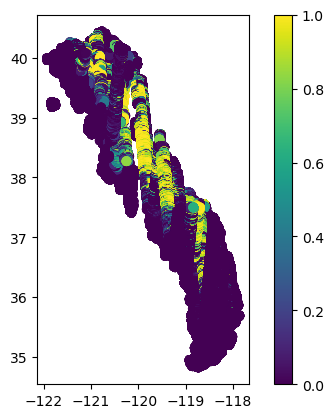

In [10]:
atl06sr_gdf.plot(column='reanalysis_fsca', legend=True)

<Axes: >

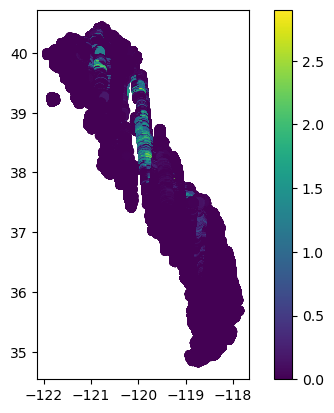

In [188]:
atl06sr_gdf.plot(column='reanalysis_sd', legend=True)

<Axes: >

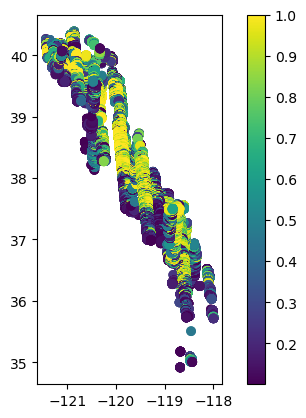

In [11]:
atl06sr_gdf[atl06sr_gdf['reanalysis_fsca']>0.1].plot(column='reanalysis_fsca', legend=True)

### Sample the reanalysis snow depth at IS2 points on corresponding dates:

In [12]:
# 2021:

for date_index in atl06sr_gdf['dowy'].unique():
    reanalysis = reanalysis_2021.SD_Post[date_index-1]
    x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index)].to_crs('epsg:4326').geometry]
    y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index)].to_crs('epsg:4326').geometry]
    atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index), ['reanalysis_sd']] = reanalysis.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T
    print('sampling date:', f'{date_index}')

sampling date: 12
sampling date: 9
sampling date: 8
sampling date: 5
sampling date: 4
sampling date: 365
sampling date: 361
sampling date: 353
sampling date: 349
sampling date: 348
sampling date: 341
sampling date: 340
sampling date: 337
sampling date: 336
sampling date: 332
sampling date: 319
sampling date: 316
sampling date: 315
sampling date: 312
sampling date: 308
sampling date: 307
sampling date: 287
sampling date: 283
sampling date: 282
sampling date: 279
sampling date: 278
sampling date: 275
sampling date: 270
sampling date: 251
sampling date: 249
sampling date: 245
sampling date: 241
sampling date: 224
sampling date: 218
sampling date: 216
sampling date: 212
sampling date: 201
sampling date: 197
sampling date: 195
sampling date: 193
sampling date: 189
sampling date: 183
sampling date: 179
sampling date: 168
sampling date: 164
sampling date: 162
sampling date: 160
sampling date: 158
sampling date: 156
sampling date: 143
sampling date: 139
sampling date: 127
sampling date: 125
sa

### Save the file:

In [187]:
atl06sr_gdf.to_pickle('../data/temp/gdf_1m_sierras_concat_sorted_processed.pkl')